# 01 - Reference Catalog Audit

Audit of the reference database and configured Phase 2 exports. This notebook verifies provenance, exported dataset sizes, astrometric retention, match provenance, and a compact photometric feature view under the `strict`/`relaxed` dataset design.

In [11]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import yaml

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

with (ROOT / 'configs/filters.yaml').open(encoding='utf-8') as fh:
    filters = yaml.safe_load(fh)
with (ROOT / filters['paths_config']).open(encoding='utf-8') as fh:
    paths = yaml.safe_load(fh)

ref_dir = ROOT / paths['processed_reference_dir']
neg_dir = ROOT / paths['processed_simbad_negative_dir']
variants = filters['color_locus']['dataset_variants']
family_order = list(filters['photometry']['families'])
subset_order = ['photometry', 'parallax_soft', 'poe_1', 'poe_2', 'poe_3', 'poe_5']


def split_variant_name(variant):
    for family in family_order:
        prefix = f'{family}_'
        if variant.startswith(prefix):
            return family, variant[len(prefix):]
    return 'legacy', variant


def variant_metadata(variant):
    family, subset = split_variant_name(variant)
    return {'dataset_variant': variant, 'dataset_family': family, 'astrometric_subset': subset}


def ordered_summary(df):
    out = df.copy()
    out['dataset_family'] = pd.Categorical(out['dataset_family'], family_order, ordered=True)
    out['astrometric_subset'] = pd.Categorical(out['astrometric_subset'], subset_order, ordered=True)
    return out.sort_values(['dataset_family', 'astrometric_subset']).reset_index(drop=True)

import duckdb

DB_PATH = ROOT / paths['wr_reference_db']
con = duckdb.connect(str(DB_PATH), read_only=True)

## Pipeline Provenance

In [12]:
tables = con.execute("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'main'
    ORDER BY table_name
""").fetchdf()
counts = []
for table in tables['table_name']:
    n = con.execute(f'SELECT COUNT(*) AS n FROM {table}').fetchone()[0]
    counts.append({'table': table, 'rows': n})
pd.DataFrame(counts)

,table,rows
0,catalog_snapshots,1
1,crossmatch_log,9
2,gaia_sources,442
3,twomass_matches,430
4,wise_matches,406
5,wr_catalog_raw,705
6,wr_reference,442


In [13]:
if 'crossmatch_log' in set(tables['table_name']):
    con.execute('SELECT * FROM crossmatch_log ORDER BY stage, method').fetchdf()
else:
    pd.DataFrame()

## Load Configured Exports

In [14]:
datasets = {}
for variant in variants:
    path = ref_dir / filters['output_files'][variant]
    df = pd.read_parquet(path)
    for key, value in variant_metadata(variant).items():
        if key not in df.columns:
            df[key] = value
    datasets[variant] = df

export_summary = ordered_summary(pd.DataFrame([
    {
        **variant_metadata(variant),
        'rows': len(df),
        'file': filters['output_files'][variant],
    }
    for variant, df in datasets.items()
]))
export_summary

,dataset_variant,dataset_family,astrometric_subset,rows,file
0,strict_photometry,strict,photometry,306,wr_reference_strict_photometry.parquet
1,strict_parallax_soft,strict,parallax_soft,259,wr_reference_strict_parallax_soft.parquet
2,strict_poe_1,strict,poe_1,222,wr_reference_strict_poe_1.parquet
3,strict_poe_2,strict,poe_2,200,wr_reference_strict_poe_2.parquet
4,strict_poe_3,strict,poe_3,181,wr_reference_strict_poe_3.parquet
5,strict_poe_5,strict,poe_5,146,wr_reference_strict_poe_5.parquet
6,relaxed_photometry,relaxed,photometry,347,wr_reference_relaxed_photometry.parquet
7,relaxed_parallax_soft,relaxed,parallax_soft,298,wr_reference_relaxed_parallax_soft.parquet
8,relaxed_poe_1,relaxed,poe_1,261,wr_reference_relaxed_poe_1.parquet
9,relaxed_poe_2,relaxed,poe_2,237,wr_reference_relaxed_poe_2.parquet


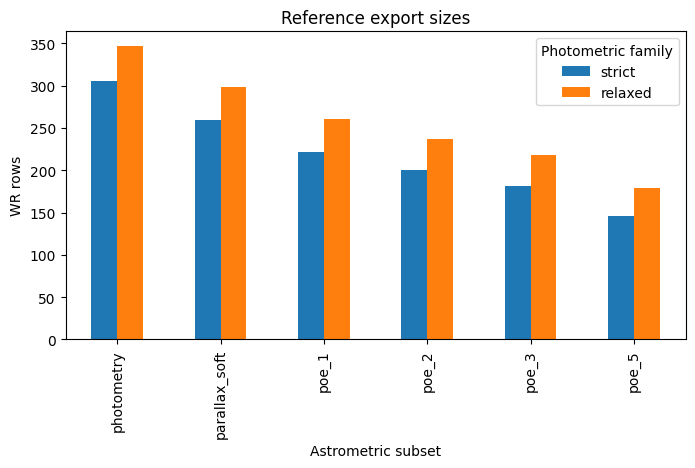

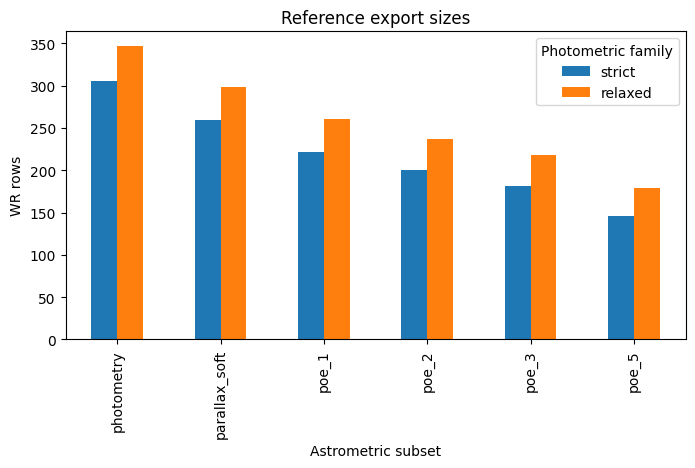

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
export_summary.pivot(index='astrometric_subset', columns='dataset_family', values='rows').loc[subset_order].plot(kind='bar', ax=ax)
ax.set_xlabel('Astrometric subset')
ax.set_ylabel('WR rows')
ax.set_title('Reference export sizes')
ax.legend(title='Photometric family')
fig

## Astrometric Quality

In [16]:
astro_rows = []
for variant, df in datasets.items():
    astro_rows.append({
        **variant_metadata(variant),
        'rows': len(df),
        'parallax_min': df['parallax'].min(),
        'parallax_median': df['parallax'].median(),
        'poe_median': df['parallax_over_error'].median(),
        'ruwe_median': df['ruwe'].median(),
    })
ordered_summary(pd.DataFrame(astro_rows))

,dataset_variant,dataset_family,astrometric_subset,rows,parallax_min,parallax_median,poe_median,ruwe_median
0,strict_photometry,strict,photometry,306,-2.354731,0.158196,4.715608,1.082953
1,strict_parallax_soft,strict,parallax_soft,259,0.000119,0.187075,6.109190,1.067342
2,strict_poe_1,strict,poe_1,222,0.027528,0.198043,7.824076,1.053987
3,strict_poe_2,strict,poe_2,200,0.053883,0.202592,9.304933,1.049270
4,strict_poe_3,strict,poe_3,181,0.053883,0.208400,10.982916,1.037965
5,strict_poe_5,strict,poe_5,146,0.053883,0.219140,12.468990,1.030926
6,relaxed_photometry,relaxed,photometry,347,-2.354731,0.171364,5.667342,1.069860
7,relaxed_parallax_soft,relaxed,parallax_soft,298,0.000119,0.201564,7.026629,1.058542
8,relaxed_poe_1,relaxed,poe_1,261,0.027528,0.209785,9.159730,1.041267
9,relaxed_poe_2,relaxed,poe_2,237,0.053883,0.215859,10.681320,1.037965


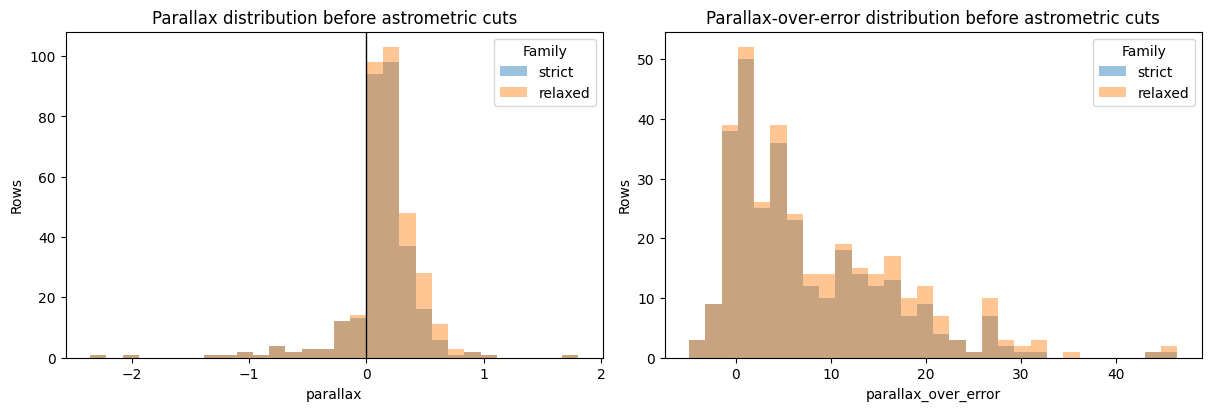

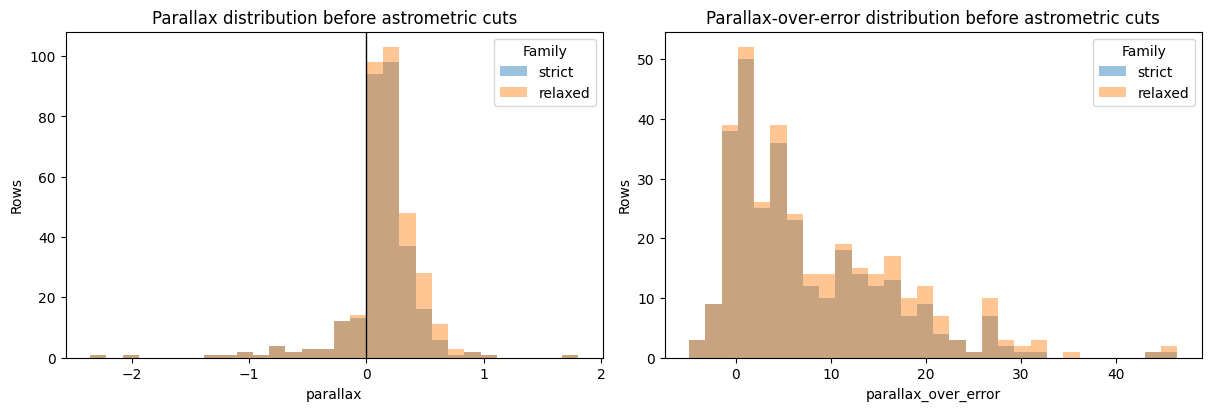

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for family in family_order:
    key = f'{family}_photometry'
    axes[0].hist(datasets[key]['parallax'].dropna(), bins=30, alpha=0.45, label=family)
    axes[1].hist(datasets[key]['parallax_over_error'].dropna(), bins=30, alpha=0.45, label=family)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Parallax distribution before astrometric cuts')
axes[0].set_xlabel('parallax')
axes[1].set_title('Parallax-over-error distribution before astrometric cuts')
axes[1].set_xlabel('parallax_over_error')
for ax in axes:
    ax.set_ylabel('Rows')
    ax.legend(title='Family')
fig

## Match Provenance

In [18]:
match_rows = []
for variant, df in datasets.items():
    for mission, col in [('2MASS', 'tmass_match_method'), ('WISE', 'wise_match_method')]:
        if col not in df.columns:
            continue
        counts = df[col].value_counts(dropna=False)
        for method, rows in counts.items():
            match_rows.append({**variant_metadata(variant), 'mission': mission, 'match_method': method, 'rows': int(rows)})
match_summary = ordered_summary(pd.DataFrame(match_rows))
match_summary

,dataset_variant,dataset_family,astrometric_subset,mission,match_method,rows
0,strict_photometry,strict,photometry,2MASS,gaia_xmatch,303
1,strict_photometry,strict,photometry,2MASS,vizier_cone,3
2,strict_photometry,strict,photometry,WISE,gaia_xmatch,225
3,strict_photometry,strict,photometry,WISE,vizier_cone,81
4,strict_parallax_soft,strict,parallax_soft,2MASS,gaia_xmatch,258
5,strict_parallax_soft,strict,parallax_soft,2MASS,vizier_cone,1
6,strict_parallax_soft,strict,parallax_soft,WISE,gaia_xmatch,195
7,strict_parallax_soft,strict,parallax_soft,WISE,vizier_cone,64
8,strict_poe_1,strict,poe_1,2MASS,gaia_xmatch,221
9,strict_poe_1,strict,poe_1,2MASS,vizier_cone,1


## Dataset Size And Quality Tradeoff

In [19]:
size_matrix = export_summary.pivot(index='astrometric_subset', columns='dataset_family', values='rows').loc[subset_order]
size_matrix['relaxed_minus_strict'] = size_matrix['relaxed'] - size_matrix['strict']
size_matrix['relaxed_over_strict'] = size_matrix['relaxed'] / size_matrix['strict']
size_matrix

dataset_family,strict,relaxed,relaxed_minus_strict,relaxed_over_strict
astrometric_subset,,,,
photometry,306,347,41,1.133987
parallax_soft,259,298,39,1.150579
poe_1,222,261,39,1.175676
poe_2,200,237,37,1.185000
poe_3,181,218,37,1.204420
poe_5,146,179,33,1.226027


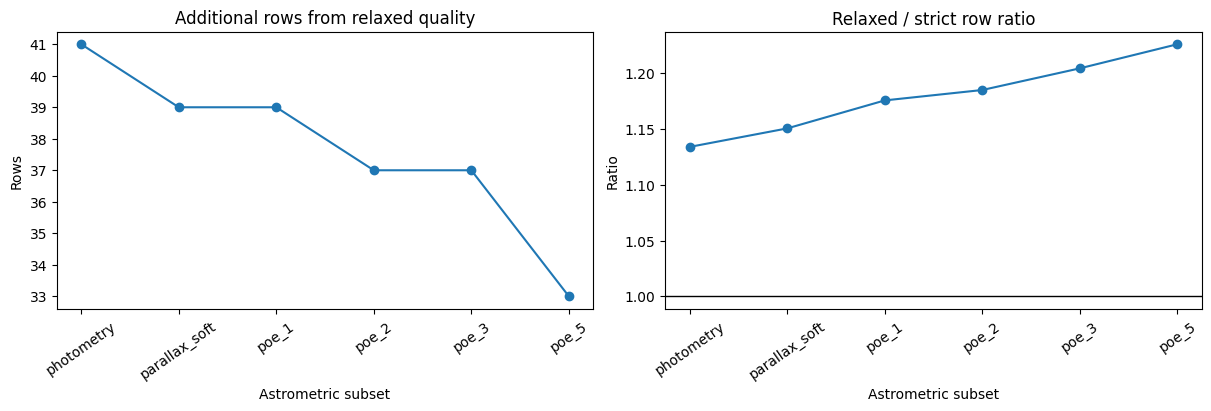

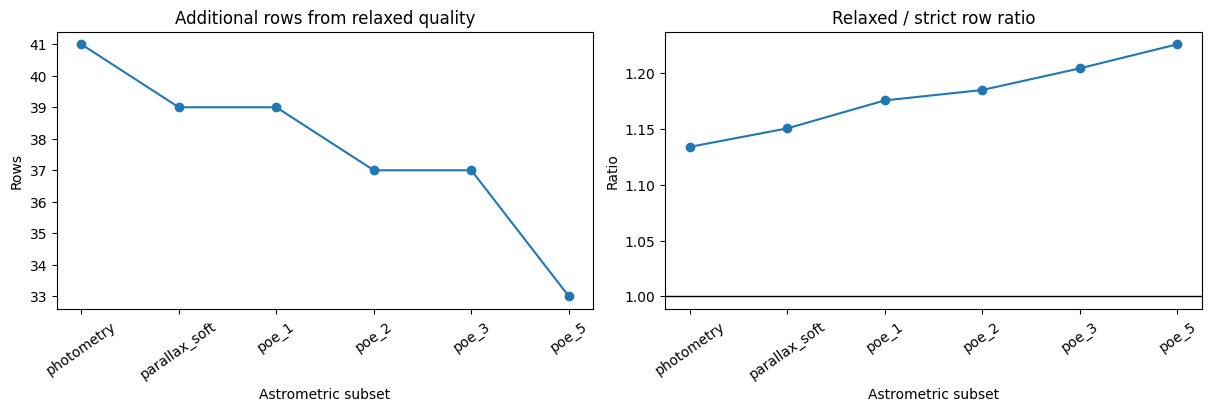

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(size_matrix.index.astype(str), size_matrix['relaxed_minus_strict'], marker='o')
axes[0].set_title('Additional rows from relaxed quality')
axes[0].set_ylabel('Rows')
axes[1].plot(size_matrix.index.astype(str), size_matrix['relaxed_over_strict'], marker='o')
axes[1].axhline(1, color='black', linewidth=1)
axes[1].set_title('Relaxed / strict row ratio')
axes[1].set_ylabel('Ratio')
for ax in axes:
    ax.set_xlabel('Astrometric subset')
    ax.tick_params(axis='x', rotation=35)
fig

## Photometric Feature Space

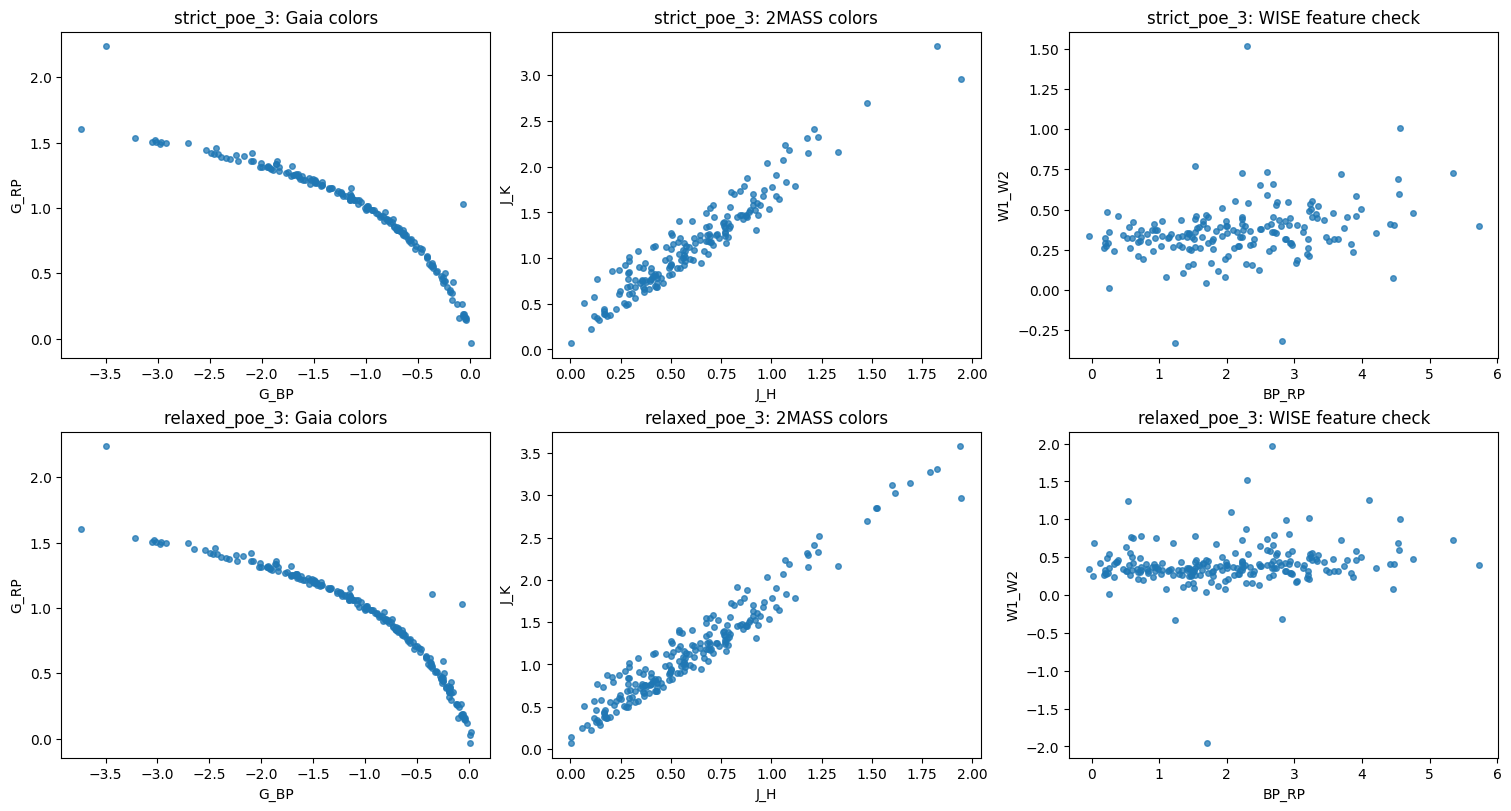

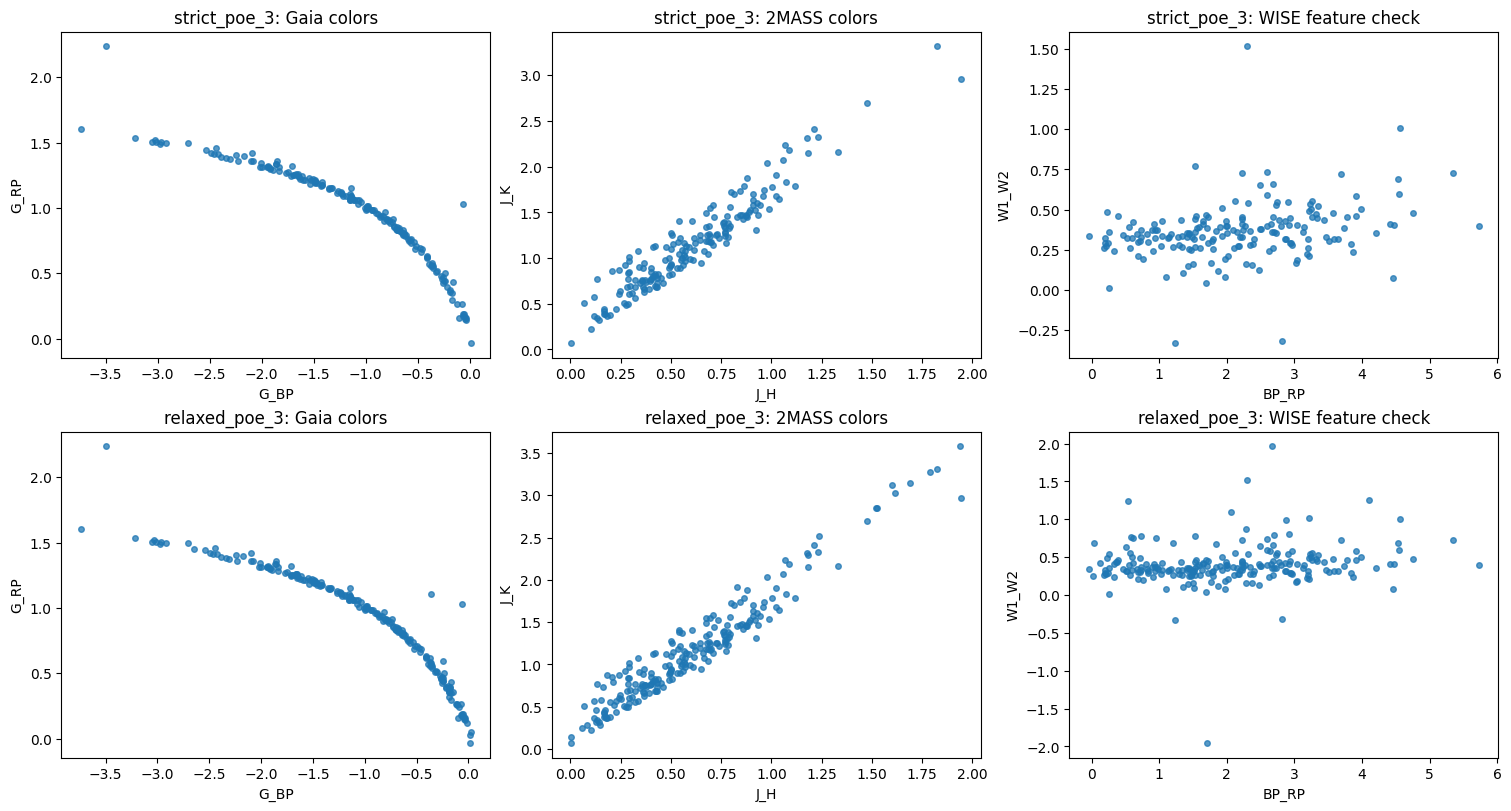

In [21]:
plot_variants = [v for v in ['strict_poe_3', 'relaxed_poe_3'] if v in datasets]
fig, axes = plt.subplots(len(plot_variants), 3, figsize=(15, 4 * len(plot_variants)), squeeze=False, constrained_layout=True)
for row, variant in enumerate(plot_variants):
    df = datasets[variant]
    axes[row, 0].scatter(df['G_BP'], df['G_RP'], s=16, alpha=0.75)
    axes[row, 0].set_xlabel('G_BP')
    axes[row, 0].set_ylabel('G_RP')
    axes[row, 0].set_title(f'{variant}: Gaia colors')
    axes[row, 1].scatter(df['J_H'], df['J_K'], s=16, alpha=0.75)
    axes[row, 1].set_xlabel('J_H')
    axes[row, 1].set_ylabel('J_K')
    axes[row, 1].set_title(f'{variant}: 2MASS colors')
    axes[row, 2].scatter(df['BP_RP'], df['W1_W2'], s=16, alpha=0.75)
    axes[row, 2].set_xlabel('BP_RP')
    axes[row, 2].set_ylabel('W1_W2')
    axes[row, 2].set_title(f'{variant}: WISE feature check')
fig

## Audit Note

`ruwe` remains an exported feature, not a hard filter. The preferred reference base is no longer a single `poe_3` file by convention; downstream modelling should choose among configured `strict_*` and `relaxed_*` variants and report that choice explicitly.

In [22]:
con.close()